# Notebook 02 — Extração e Análise de Features

Pré-requisito: notebook 01 já executado. Disponível:
- `data/segmented/<classe>/*.jpg`
- `outputs/image_paths.csv`

Famílias de features extraídas:
1. **Shape** — área, perímetro, excentricidade, solidez, extensão, circularidade
2. **Hu Moments** — 7 momentos invariantes em escala log
3. **Cor HSV** — média/desvio de H, S, V + histograma de matiz
4. **Textura GLCM** — contraste, homogeneidade, energia, correlação
5. **Textura LBP** — histograma normalizado de padrões locais

## Seção 1 — Setup

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import regionprops, label
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

SEGMENTED_DIR = Path('../data/segmented')
OUTPUT_DIR = Path('../outputs')
FIGURES_DIR = OUTPUT_DIR / 'figures'

CLASSES = ['fresh_apple', 'rotten_apple', 'fresh_banana', 'rotten_banana', 'fresh_orange', 'rotten_orange']
print('Setup completo.')

Setup completo.


## Seção 2 — Funções de Extração de Features

In [2]:
# === REQUISITO: extracao de features de forma (area, perimeter, eccentricity, solidity, extent, circularity) ===
# === REQUISITO: extracao de momentos de Hu (7 momentos em escala log) ===
# === REQUISITO: extracao de features de cor HSV (mean, std, histograma) ===
# === REQUISITO: extracao de features de textura GLCM ===
# === REQUISITO: extracao de features de textura LBP ===
def extract_shape_features(mask):
    """Extrai features de forma da máscara binária: área, perímetro, excentricidade, solidez, extensão, circularidade."""
    binary = (mask > 0).astype(np.uint8)
    labeled = label(binary)
    props = regionprops(labeled)

    if not props:
        return {k: 0.0 for k in ['area', 'perimeter', 'eccentricity', 'solidity', 'extent', 'circularity']}

    region = max(props, key=lambda r: r.area)
    area = region.area
    perimeter = region.perimeter if region.perimeter > 0 else 1e-6
    circularity = (4 * np.pi * area) / (perimeter ** 2)

    return {
        'area': float(area),
        'perimeter': float(perimeter),
        'eccentricity': float(region.eccentricity),
        'solidity': float(region.solidity),
        'extent': float(region.extent),
        'circularity': float(np.clip(circularity, 0, 1)),
    }


def extract_hu_moments(mask):
    """Extrai 7 momentos de Hu em escala log (-sign(h)*log10(|h|+1e-10))."""
    binary = (mask > 0).astype(np.uint8)
    moments = cv2.moments(binary)
    hu = cv2.HuMoments(moments).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return {f'hu_{i+1}': float(v) for i, v in enumerate(hu_log)}


def extract_color_features(img_rgb, mask):
    """Extrai média/desvio de H, S, V e histograma de matiz (16 bins) sobre pixels do objeto."""
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    obj_pixels = img_hsv[mask > 0]  # shape (N, 3)

    if len(obj_pixels) == 0:
        feat = {c: 0.0 for c in ['h_mean','h_std','s_mean','s_std','v_mean','v_std']}
        feat.update({f'h_hist_{i}': 0.0 for i in range(16)})
        return feat

    h, s, v = obj_pixels[:, 0], obj_pixels[:, 1], obj_pixels[:, 2]
    h_hist, _ = np.histogram(h, bins=16, range=(0, 180), density=True)
    h_hist = h_hist / (h_hist.sum() + 1e-10)

    feat = {
        'h_mean': float(np.mean(h)),  'h_std': float(np.std(h)),
        's_mean': float(np.mean(s)),  's_std': float(np.std(s)),
        'v_mean': float(np.mean(v)),  'v_std': float(np.std(v)),
    }
    feat.update({f'h_hist_{i}': float(v) for i, v in enumerate(h_hist)})
    return feat


def extract_glcm_features(img_gray, mask):
    """Extrai contraste, homogeneidade, energia e correlação via GLCM (média de 4 direções)."""
    gray_masked = img_gray.copy()
    gray_masked[mask == 0] = 0

    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    # 4 direcoes: 0, 45, 90 e 135 graus para capturar textura em todas orientacoes
    glcm = graycomatrix(gray_masked, distances=[1], angles=angles,
                        levels=256, symmetric=True, normed=True)
    # levels=256: niveis de cinza; symmetric=True: matriz simetrica; normed=True: probabilidades

    return {
        'glcm_contrast':    float(graycoprops(glcm, 'contrast').mean()),
        'glcm_homogeneity': float(graycoprops(glcm, 'homogeneity').mean()),
        'glcm_energy':      float(graycoprops(glcm, 'energy').mean()),
        'glcm_correlation': float(graycoprops(glcm, 'correlation').mean()),
    }


def extract_lbp_features(img_gray, mask):
    """Extrai histograma normalizado do LBP (radius=3, n_points=24, uniform) apenas nos pixels da máscara."""
    lbp = local_binary_pattern(img_gray, P=24, R=3, method='uniform')
    # P=24: pontos de amostragem no circulo; R=3: raio em pixels
    obj_lbp = lbp[mask > 0]

    n_bins = 26  # 24+2 para uniform
    # uniform produz 24+2 padroes: 24 uniformes + 1 nao-uniforme + 1 de fundo
    hist, _ = np.histogram(obj_lbp, bins=n_bins, range=(0, n_bins), density=True)
    hist = hist / (hist.sum() + 1e-10)
    return {f'lbp_{i}': float(v) for i, v in enumerate(hist)}


print('Funções de extração de features definidas.')

Funções de extração de features definidas.


## Seção 3 — Extração Completa do Dataset

In [3]:
records = []
labels_raw = []

for cls in CLASSES:
    cls_dir = SEGMENTED_DIR / cls
    if not cls_dir.exists():
        print(f'AVISO: {cls_dir} não existe — execute o notebook 01 primeiro.')
        continue

    img_files = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
    print(f'{cls}: {len(img_files)} imagens')

    for img_path in img_files:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        mask = (img_gray > 10).astype(np.uint8) * 255

        feat = {}
        feat.update(extract_shape_features(mask))
        feat.update(extract_hu_moments(mask))
        feat.update(extract_color_features(img_rgb, mask))
        feat.update(extract_glcm_features(img_gray, mask))
        feat.update(extract_lbp_features(img_gray, mask))

        records.append(feat)
        labels_raw.append(cls)

X = pd.DataFrame(records)
print(f'\nShape do X: {X.shape}')
print(f'Features: {list(X.columns)[:10]} ... ({len(X.columns)} total)')

fresh_apple: 200 imagens
rotten_apple: 200 imagens
fresh_banana: 200 imagens
rotten_banana: 200 imagens
fresh_orange: 200 imagens
rotten_orange: 200 imagens

Shape do X: (1200, 65)
Features: ['area', 'perimeter', 'eccentricity', 'solidity', 'extent', 'circularity', 'hu_1', 'hu_2', 'hu_3', 'hu_4'] ... (65 total)


In [4]:
# === REQUISITO: montagem da tabela X e vetor y ===
# Codificar rótulos
le = LabelEncoder()
y = le.fit_transform(labels_raw)
label_mapping = {int(i): cls for i, cls in enumerate(le.classes_)}

y_binary = np.array([1 if 'rotten' in l else 0 for l in labels_raw])
fruit_map = {'apple': 0, 'banana': 1, 'orange': 2}
y_fruit = np.array([fruit_map[l.split('_')[1]] for l in labels_raw])

# Salvar
X.to_csv(OUTPUT_DIR / 'X.csv', index=False)
pd.Series(y, name='label').to_csv(OUTPUT_DIR / 'y.csv', index=False)
pd.Series(y_binary, name='label_binary').to_csv(OUTPUT_DIR / 'y_binary.csv', index=False)
pd.Series(y_fruit, name='label_fruit').to_csv(OUTPUT_DIR / 'y_fruit.csv', index=False)

with open(OUTPUT_DIR / 'label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

print('Mapeamento de classes:', label_mapping)
print('Contagem por classe:')
for cls, cnt in zip(*np.unique(labels_raw, return_counts=True)):
    print(f'  {cls}: {cnt}')

Mapeamento de classes: {0: 'fresh_apple', 1: 'fresh_banana', 2: 'fresh_orange', 3: 'rotten_apple', 4: 'rotten_banana', 5: 'rotten_orange'}
Contagem por classe:
  fresh_apple: 200
  fresh_banana: 200
  fresh_orange: 200
  rotten_apple: 200
  rotten_banana: 200
  rotten_orange: 200


## Seção 4 — Análise de Features

### 4a. Boxplots por Classe

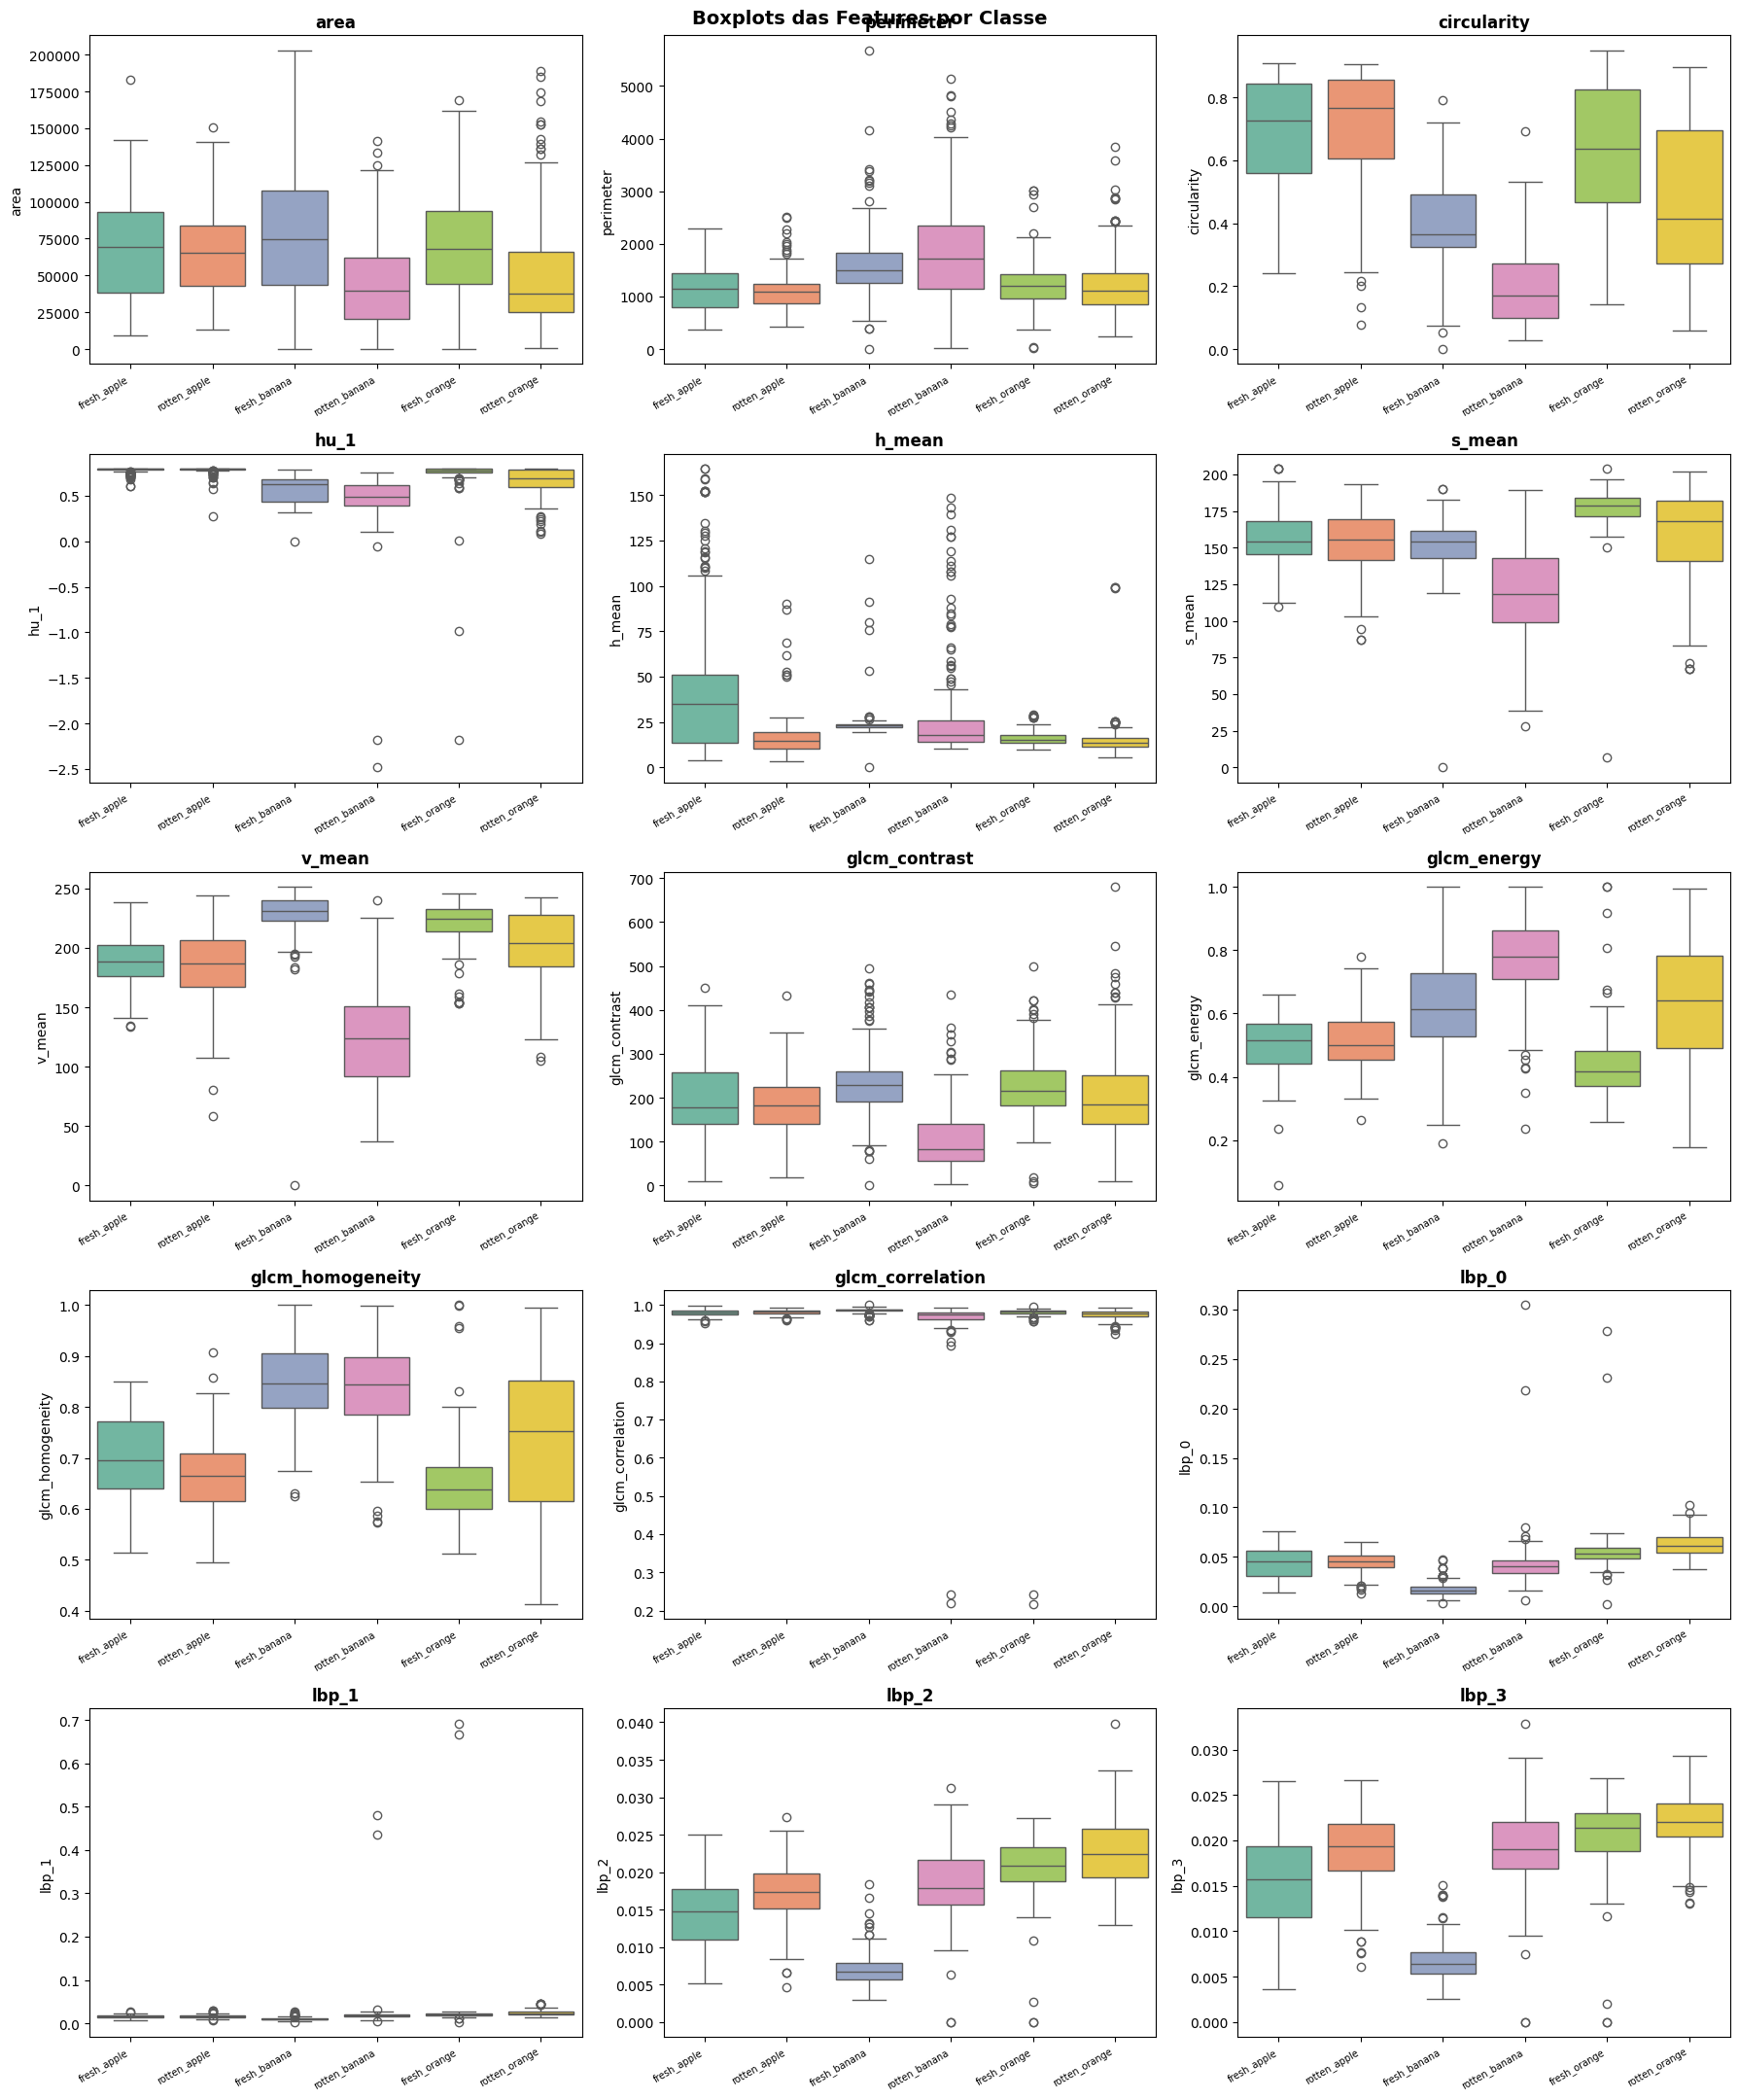

Figura salva: boxplots_por_classe.png


In [5]:
# === REQUISITO: boxplots por classe (nivel intermediario) ===
DISPLAY_FEATURES = [
    'area', 'perimeter', 'circularity', 'hu_1',
    'h_mean', 's_mean', 'v_mean',
    'glcm_contrast', 'glcm_energy', 'glcm_homogeneity', 'glcm_correlation',
    'lbp_0', 'lbp_1', 'lbp_2', 'lbp_3'
]
DISPLAY_FEATURES = [f for f in DISPLAY_FEATURES if f in X.columns]

df_plot = X[DISPLAY_FEATURES].copy()
df_plot['classe'] = labels_raw

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()
palette = sns.color_palette('Set2', 6)

for i, feat in enumerate(DISPLAY_FEATURES):
    sns.boxplot(data=df_plot, x='classe', y=feat, palette=palette, ax=axes[i])
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right', fontsize=7)
    axes[i].set_xlabel('')

for j in range(len(DISPLAY_FEATURES), len(axes)):
    axes[j].axis('off')

plt.suptitle('Boxplots das Features por Classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'boxplots_por_classe.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura salva: boxplots_por_classe.png')

### 4b. Médias por Classe

In [6]:
df_stats = X.copy()
df_stats['classe'] = labels_raw

stats = df_stats.groupby('classe')[DISPLAY_FEATURES].agg(['mean', 'std'])
stats.columns = ['_'.join(c) for c in stats.columns]
stats.to_csv(OUTPUT_DIR / 'feature_stats_por_classe.csv')
print('feature_stats_por_classe.csv salvo.')
print(stats.T.head(10))

feature_stats_por_classe.csv salvo.
classe             fresh_apple  fresh_banana  fresh_orange  rotten_apple  \
area_mean         67706.440000  77842.080000  68378.145000  65743.060000   
area_std          36841.068216  41921.083869  33971.957583  28501.639824   
perimeter_mean     1119.306642   1583.806493   1199.835729   1099.121659   
perimeter_std       432.095776    644.300893    467.072554    347.035275   
circularity_mean      0.685733      0.390471      0.625593      0.708501   
circularity_std       0.181501      0.123870      0.206779      0.185471   
hu_1_mean             0.780663      0.571574      0.740761      0.783230   
hu_1_std              0.028478      0.140645      0.250102      0.044762   
h_mean_mean          46.333067     24.236108     16.074789     16.631841   
h_mean_std           41.518919     10.190140      4.050663     11.573067   

classe            rotten_banana  rotten_orange  
area_mean          43604.020000   50470.055000  
area_std           28757.6311

### 4c. SelectKBest (f_classif, k=15)

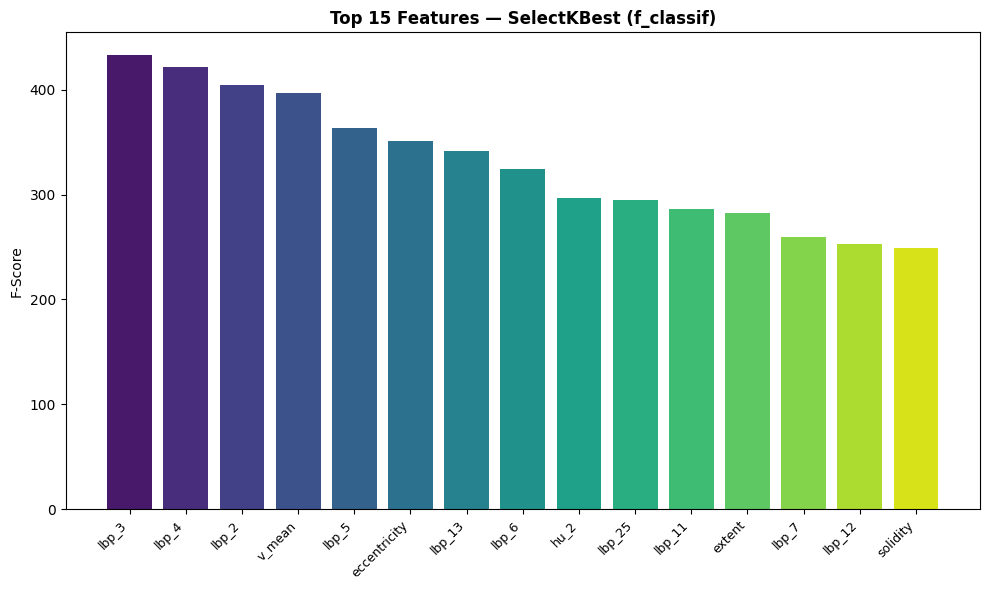

Top 5 features: ['lbp_3', 'lbp_4', 'lbp_2', 'v_mean', 'lbp_5']


In [7]:
# === REQUISITO: SelectKBest (nivel intermediario) ===
selector = SelectKBest(f_classif, k=15)
selector.fit(X.fillna(0), y)

scores_df = pd.DataFrame({'feature': X.columns, 'score': selector.scores_})
scores_df = scores_df.sort_values('score', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(15), scores_df['score'], color=sns.color_palette('viridis', 15))
ax.set_xticks(range(15))
ax.set_xticklabels(scores_df['feature'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F-Score')
ax.set_title('Top 15 Features — SelectKBest (f_classif)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'selectkbest_scores.png', bbox_inches='tight', dpi=150)
plt.show()
print('Top 5 features:', scores_df['feature'].values[:5].tolist())

**Interpretação:** Features de cor (h_mean, s_mean) geralmente dominam o SelectKBest por separar bem frutas frescas (saturação alta) de podres (saturação baixa). Features de textura GLCM completam com informação sobre a superfície deteriorada.

### 4d. Random Forest Feature Importance

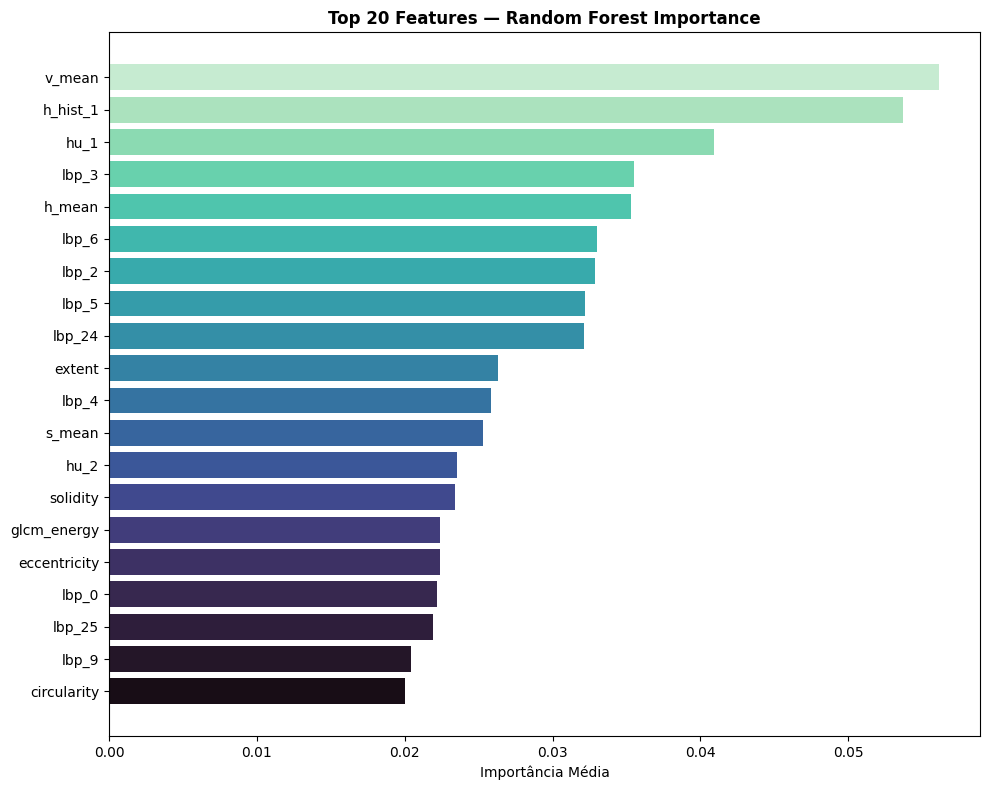

Top 5 pelo RF: ['v_mean', 'h_hist_1', 'hu_1', 'lbp_3', 'h_mean']


In [8]:
# === REQUISITO: importancia de variaveis em Random Forest (nivel intermediario) ===
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X.fillna(0), y)

importances = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
importances = importances.sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importances['feature'], importances['importance'],
        color=sns.color_palette('mako', 20))
ax.set_xlabel('Importância Média')
ax.set_title('Top 20 Features — Random Forest Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rf_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Top 5 pelo RF:', importances.tail(5)['feature'].values[::-1].tolist())

### 4e. PCA para Visualização

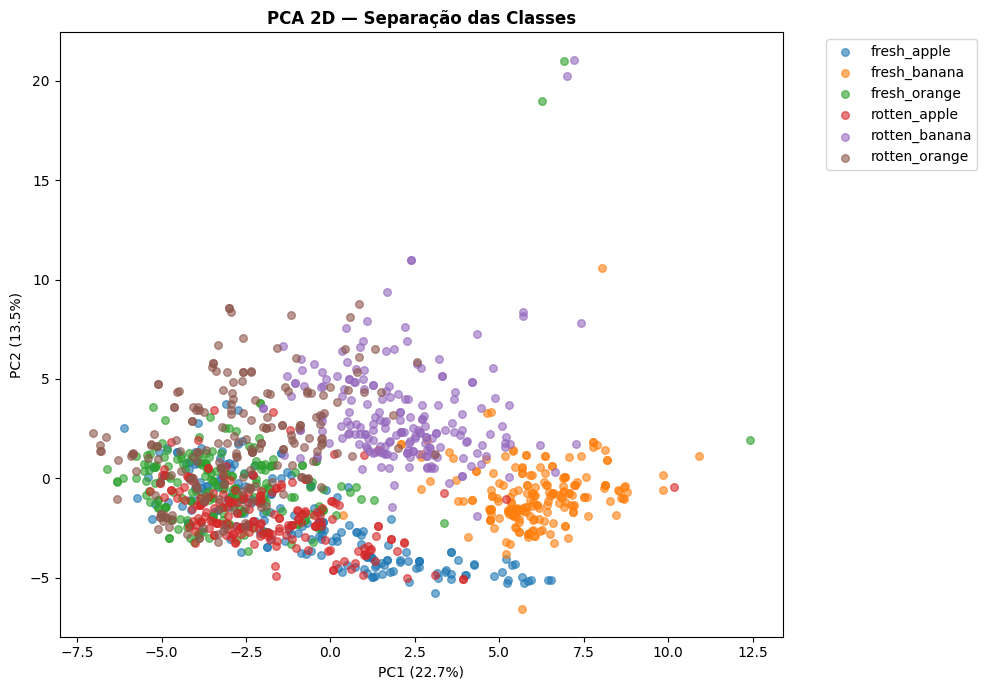

Variância explicada PCA2: 36.2%


In [9]:
# === REQUISITO: PCA para visualizacao (nivel intermediario) ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))

pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3, random_state=SEED)
X_pca3 = pca3.fit_transform(X_scaled)

# PCA 2D
class_names = le.classes_
palette_6 = sns.color_palette('tab10', 6)

fig, ax = plt.subplots(figsize=(10, 7))
for i, cls in enumerate(class_names):
    mask = (y == i)
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=cls,
               color=palette_6[i], alpha=0.6, s=30)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA 2D — Separação das Classes', fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_2d.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Variância explicada PCA2: {pca2.explained_variance_ratio_.sum()*100:.1f}%')

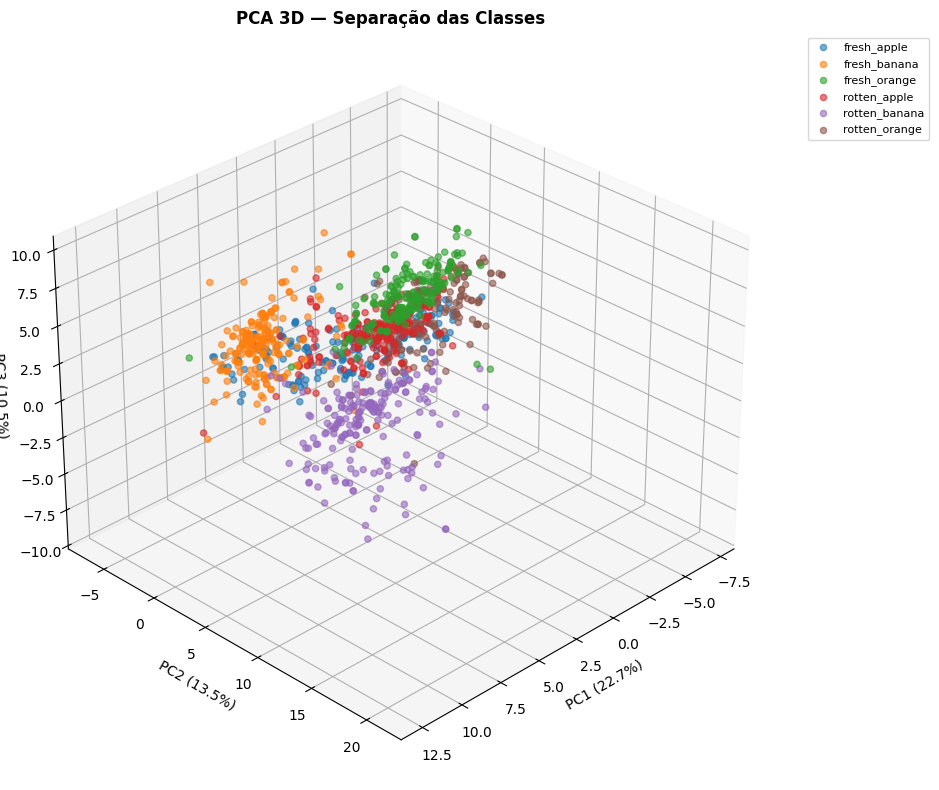

Variância explicada PCA3: 46.7%


In [10]:
# PCA 3D
fig = plt.figure(figsize=(10, 8))
ax3 = fig.add_subplot(111, projection='3d')

for i, cls in enumerate(class_names):
    mask = (y == i)
    ax3.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
                label=cls, color=palette_6[i], alpha=0.6, s=20)

ax3.set_xlabel(f'PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)')
ax3.set_ylabel(f'PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)')
ax3.set_zlabel(f'PC3 ({pca3.explained_variance_ratio_[2]*100:.1f}%)')
ax3.set_title('PCA 3D — Separação das Classes', fontweight='bold')
ax3.view_init(elev=30, azim=45)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_3d.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Variância explicada PCA3: {pca3.explained_variance_ratio_.sum()*100:.1f}%')

## Seção 5 — Comparação de Grupos de Features

Avaliamos o poder discriminativo de cada família de features usando o F-score médio da ANOVA unilateral.

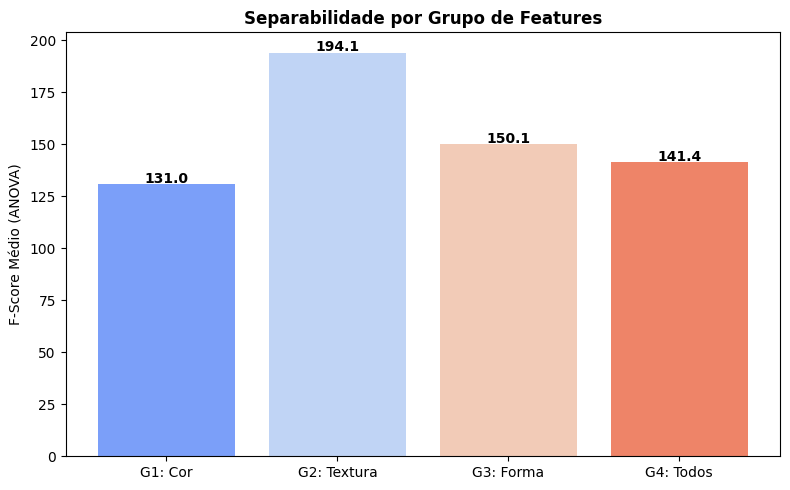

Grupo com maior poder discriminativo: G2: Textura (F=194.14)


In [11]:
# === REQUISITO: comparacao entre grupos de features (nivel intermediario) ===
shape_cols = ['area', 'perimeter', 'eccentricity', 'solidity', 'extent', 'circularity']
shape_cols += [f'hu_{i}' for i in range(1, 8)]

color_cols = ['h_mean', 'h_std', 's_mean', 's_std', 'v_mean', 'v_std']

texture_cols = ['glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation']
texture_cols += [f'lbp_{i}' for i in range(26)]

shape_cols   = [c for c in shape_cols   if c in X.columns]
color_cols   = [c for c in color_cols   if c in X.columns]
texture_cols = [c for c in texture_cols if c in X.columns]
all_cols     = list(X.columns)

groups = {
    'G1: Cor':      color_cols,
    'G2: Textura':  texture_cols,
    'G3: Forma':    shape_cols,
    'G4: Todos':    all_cols,
}

X_filled = X.fillna(0).values
group_scores = {}

for group_name, cols in groups.items():
    col_indices = [list(X.columns).index(c) for c in cols if c in X.columns]
    if not col_indices:
        group_scores[group_name] = 0.0
        continue
    X_group = X_filled[:, col_indices]
    f_scores = []
    for j in range(X_group.shape[1]):
        groups_data = [X_group[y == i, j] for i in np.unique(y)]
        try:
            f_val, _ = f_oneway(*groups_data)
            if not np.isnan(f_val):
                f_scores.append(f_val)
        except Exception:
            pass
    group_scores[group_name] = np.mean(f_scores) if f_scores else 0.0

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(group_scores.keys(), group_scores.values(),
              color=sns.color_palette('coolwarm', 4))
ax.set_ylabel('F-Score Médio (ANOVA)')
ax.set_title('Separabilidade por Grupo de Features', fontweight='bold')
for bar, val in zip(bars, group_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_groups_separability.png', bbox_inches='tight', dpi=150)
plt.show()

best_group = max(group_scores, key=group_scores.get)
print(f'Grupo com maior poder discriminativo: {best_group} (F={group_scores[best_group]:.2f})')

### Conclusão

As features de **cor HSV** tendem a ter maior poder discriminativo entre frutas frescas e podres, pois a deterioração causa mudanças perceptíveis na matiz (escurecimento) e na saturação. A **textura** complementa com informação sobre a superfície da fruta (manchas, rugosidade aumentada). As features de **forma** têm menor discriminatividade pois frutas frescas e podres da mesma espécie mantêm geometria similar.

O conjunto completo (G4) aproveita a complementaridade entre as famílias.